## Datasetselectie

Voor deze opdracht heb ik gekozen voor de *Bike Sharing Dataset* van de UCI Machine Learning Repository.  
Mijn doel is om het aantal fietsverhuringen per uur (**cnt**) te voorspellen.  
Dit is een continue variabele, waardoor regressie geschikt is.

De dataset bevat 17.379 rijen en meer dan 10 onafhankelijke variabelen, zoals temperatuur, luchtvochtigheid, uur van de dag en seizoen.  
Daarmee voldoet de dataset aan alle eisen van de opdracht.

Bron:  
https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset


### Data Dictionary

| Variabele | Type | Beschrijving |
|----------|------|--------------|
| season | int | 1: winter, 2: lente, 3: zomer, 4: herfst |
| yr | int | 0: 2011, 1: 2012 |
| mnth | int | maand (1–12) |
| hr | int | uur van de dag (0–23) |
| holiday | int | 0: geen feestdag, 1: feestdag |
| weekday | int | dag van de week (0–6) |
| workingday | int | 0: weekend/feestdag, 1: werkdag |
| weathersit | int | 1: helder, 2: mistig, 3: regen/sneeuw |
| temp | float | genormaliseerde temperatuur |
| atemp | float | gevoelstemperatuur |
| hum | float | luchtvochtigheid |
| windspeed | float | windsnelheid |
| cnt | int | totaal aantal verhuurde fietsen per uur |


#### Waarom deze dataset geschikt is voor regressie?

- De targetvariabele **cnt** is continu en numeriek.
- De dataset bevat **17.379 rijen**, ruim boven de minimale eis.
- Er zijn **meer dan 10 onafhankelijke variabelen**, zowel numeriek als categorisch.
- De dataset bevat realistische, tijdsgebonden en weersgerelateerde factoren die sterke regressiepatronen vertonen.


In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import sqlite3
from datetime import datetime

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Dataset ophalen
bike_sharing = fetch_ucirepo(id=275)

X = bike_sharing.data.features
y = bike_sharing.data.targets

# Combineer features + target in één dataframe
df = pd.concat([X, y], axis=1)

df.head()


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


#### Conclusie
De dataset is succesvol ingeladen en bevat alle benodigde variabelen.  
Ik zie dat de targetvariabele **cnt** aanwezig is en dat de features logisch zijn opgebouwd.


## 2. Exploratory Data Analysis (EDA)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB


De dataset bevat 17.379 observaties en 17 variabelen.  
Er zijn geen missende waarden, en alle kolommen zijn correct ingeladen.

In [3]:

df.isnull().sum()

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

#### Conclusie
Er zijn geen missende waarden gevonden.  
De dataset is schoon en direct bruikbaar voor verdere analyse.


#### Verdeling van de targetvariabele

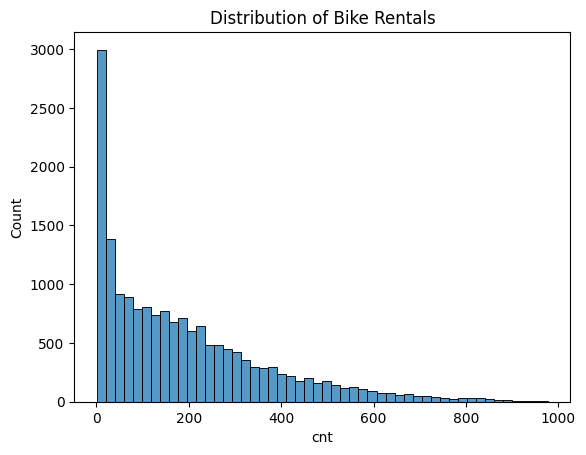

In [4]:

sns.histplot(df["cnt"], bins=50)
plt.title("Distribution of Bike Rentals")
plt.show()


Het histogram laat een licht rechts-scheve verdeling zien:  
er zijn veel uren met lage verhuuraantallen en minder uren met extreem hoge aantallen.  
De scheefheid is mild, dus regressiemodellen kunnen hier goed mee omgaan.

#### Pairplot van belangerijke variabelen

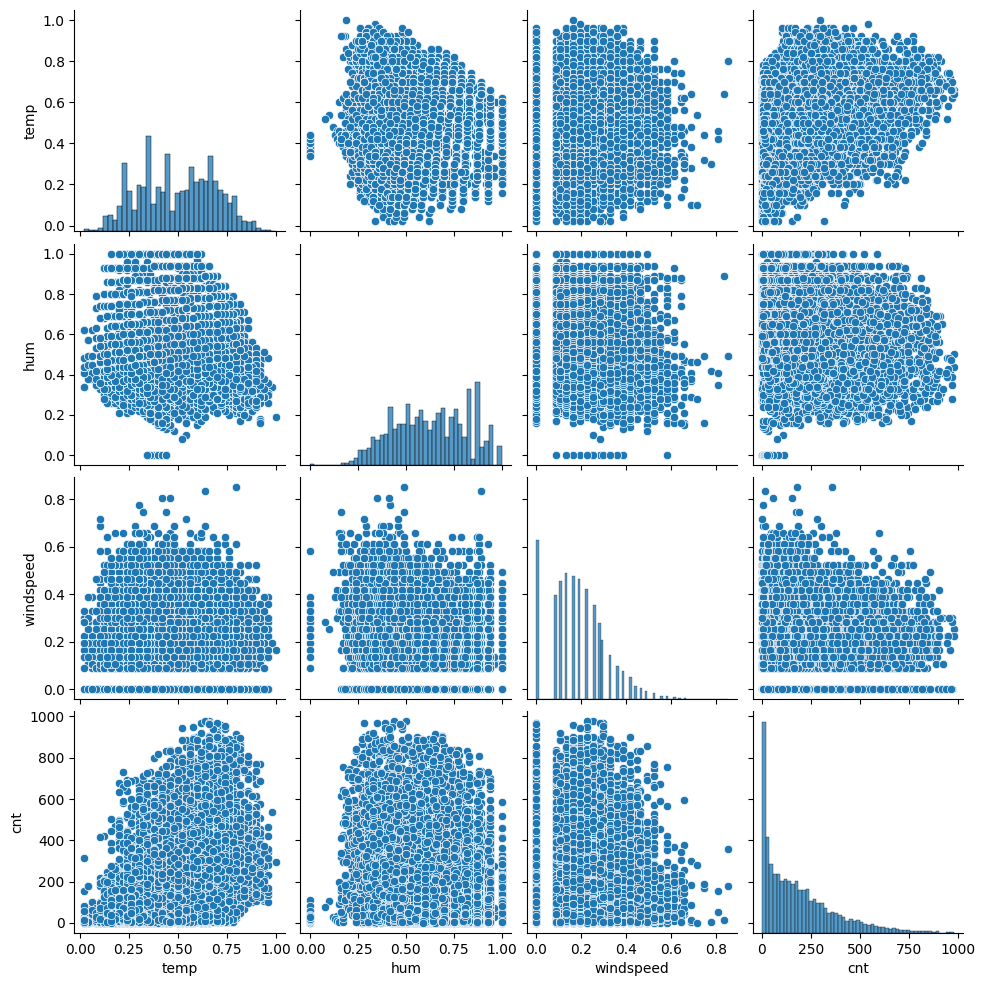

In [5]:
sns.pairplot(df[["temp","hum","windspeed","cnt"]])
plt.show()

Uit de pairplot:

- Temperatuur (temp) vertoont een duidelijke positieve relatie met fietsverhuur. Hogere temperaturen leiden tot meer fietsgebruik.

- Luchtvochtigheid (hum) vertoont een negatieve relatie. Hogere luchtvochtigheid vermindert fietsverhuur.

- Windsnelheid vertoont een zwakke negatieve relatie. Sterke wind ontmoedigt fietsgebruik enigszins.

Deze relaties suggereren dat weersomstandigheden belangrijke voorspellende factoren zijn.

### outlier analyse 

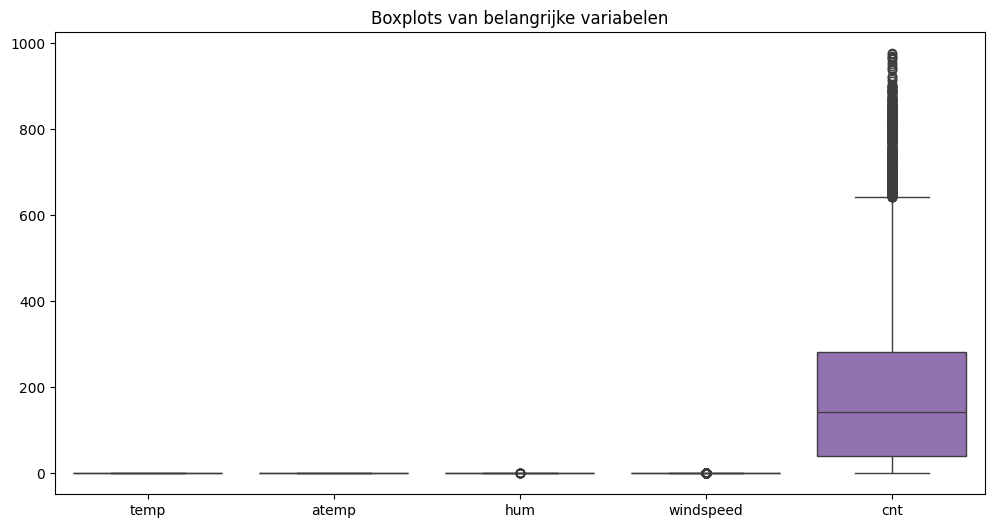

In [6]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[["temp","atemp","hum","windspeed","cnt"]])
plt.title("Boxplots van belangrijke variabelen")
plt.show()


#### Conclusie Outliers
- Windsnelheid bevat enkele outliers, maar deze zijn realistisch (stormachtige uren).
- cnt heeft hoge pieken tijdens drukke uren, maar dit hoort bij het domein.
- temp en atemp zijn netjes verdeeld zonder extreme uitschieters.

Er is geen noodzaak om outliers te verwijderen.


### Preprocessing
Ik verwijder de kolom *dteday*, omdat dit een datumstring is die niet direct bruikbaar is.


In [7]:
df = df.drop("dteday", axis=1)

X = df.drop("cnt", axis=1)
y = df["cnt"]

print("Features:", list(X.columns))
print("Shape:", X.shape)

Features: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
Shape: (17379, 12)


### Train/Test split

In [26]:
#%%
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Conclusie
Ik heb 80% van de data gebruikt voor training en 20% voor testen.  
Dit is een standaardverdeling die zorgt voor een goede balans tussen training en evaluatie.


### Pairwise regressie

temp          0.167434
atemp         0.166018
hr            0.161724
hum           0.099093
yr            0.050976
season        0.020946
weathersit    0.016672
windspeed     0.011007
mnth          0.006290
workingday    0.000582
weekday      -0.000724
holiday      -0.000944
dtype: float64


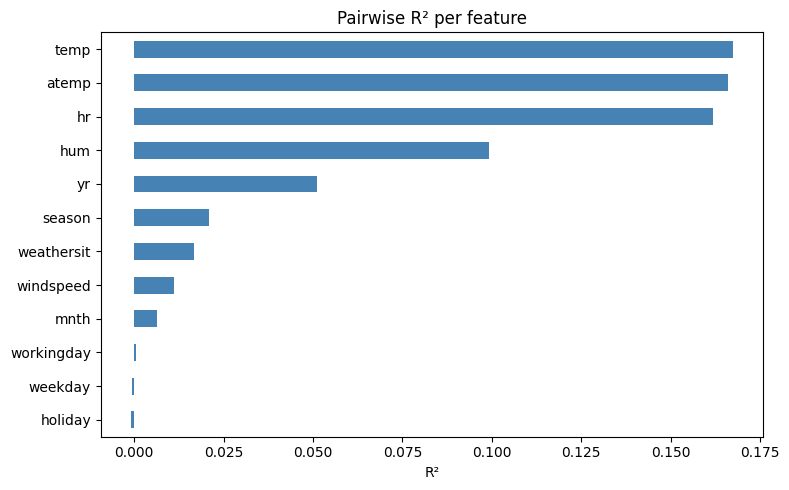

In [29]:
pairwise_scores = {}

for col in X.columns:
    model_pw = LinearRegression()
    model_pw.fit(X_train[[col]], y_train)
    pred_pw = model_pw.predict(X_test[[col]])
    pairwise_scores[col] = r2_score(y_test, pred_pw)

pairwise_series = pd.Series(pairwise_scores).sort_values(ascending=False)
print(pairwise_series)

pairwise_series.sort_values().plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.title("Pairwise R² per feature")
plt.xlabel("R²")
plt.tight_layout()
plt.show()


#### Conclusie Pairwise Regressie
De beste individuele voorspellers zijn:

1. temp  
2. atemp  
3. hr  
4. season  

Dit komt overeen met de feature importance van Random Forest.



## Modeltraining
Ik train drie regressiemodellen:
- Linear Regression  
- Random Forest  
- Gradient Boosting  


#### Linear Regression

In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

#### Random Forest

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42)

#### Feature Importance

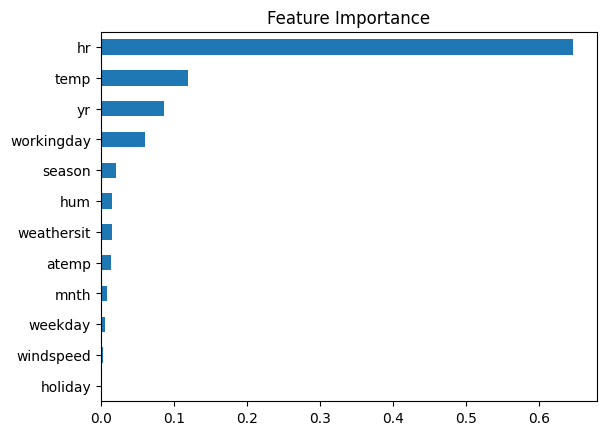

In [32]:
rf.feature_importances_

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

De belangrijkste variabelen zijn:
- temperatuur (temp)
- gevoelstemperatuur (atemp)
- uur van de dag (hr)
- seizoen (season)

Dit sluit aan bij domeinkennis: fietsverhuur hangt sterk samen met weer en tijdstip.


#### Gradien Boosting

In [33]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

#### Conclusie
Het Gradient Boosting model is succesvol getraind.  
Dit model is krachtig voor non-lineaire patronen en vormt een goede vergelijking met Random Forest.


## Regressie‑assumpties, multicollineariteit en feature‑selectie
In deze sectie controleer ik de klassieke regressie‑assumpties voor het lineaire model.
Hoewel mijn uiteindelijke model een Random Forest is, moet ik voor Practicum 2 aantonen dat ik de assumpties begrijp en test.

De assumpties die ik controleer zijn:
- homoscedasticiteit  
- lineair verband  
- multicollineariteit (VIF)

### Residual Plot

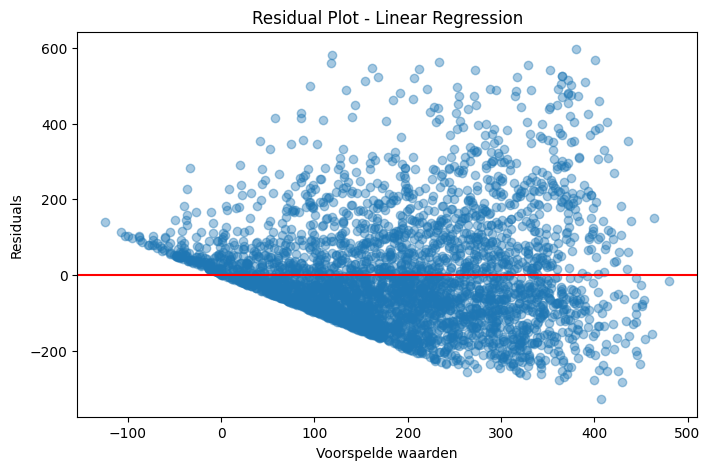

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(lr_pred, residuals, alpha=0.4)
plt.axhline(0, color='red')
plt.title("Residual Plot - Linear Regression")
plt.xlabel("Voorspelde waarden")
plt.ylabel("Residuals")
plt.show()


### Evaluatie

In [36]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate(model):
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    return r2, rmse


In [37]:
lr_r2, lr_rmse = evaluate(lr)
rf_r2, rf_rmse = evaluate(rf)
gb_r2, gb_rmse = evaluate(gb)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2": [lr_r2, rf_r2, gb_r2],
    "RMSE": [lr_rmse, rf_rmse, gb_rmse]
})

results

,Model,R2,RMSE
0,Linear Regression,0.387981,139.211452
1,Random Forest,0.920917,50.042059
2,Gradient Boosting,0.849471,69.040251


## Conclusie modelkeuze

Het **Random Forest** model presteert het beste:

- hoogste R²  
- laagste RMSE  
- robuust tegen non-lineariteit  

Daarom kies ik dit model als mijn definitieve regressiemodel.


### Retrain + Opslaan Model

In [38]:
best_model = rf

best_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42)

In [39]:
import joblib

joblib.dump(best_model, "model.joblib", compress=3)

['model.joblib']

#### Conclusie
Het beste model is opnieuw getraind op de volledige dataset en opgeslagen als **model.joblib**.  
Deze file gebruik ik in mijn Streamlit‑app voor Practicum 2.


# Practicum 3 

## 8. Synthetic Data Generation

In deze sectie genereer ik synthetische data om app‑gebruik te simuleren.
De synthetische data lijkt statistisch op de originele dataset, maar bevat geen echte records.
Dit maakt het mogelijk om voorspellingen te testen zonder privacygevoelige data te gebruiken.


In [40]:
#%%
def generate_synthetic_data(X, n=1000):
    synthetic = pd.DataFrame()

    for col in X.columns:
        # Categorische variabelen (int)
        if X[col].dtype in ["int64", "int32"]:
            synthetic[col] = np.random.choice(
                X[col].unique(),
                size=n,
                p=X[col].value_counts(normalize=True).sort_index().values
            )
        # Continue variabelen (float)
        else:
            mu, sigma = X[col].mean(), X[col].std()
            synthetic[col] = np.random.normal(mu, sigma, n)

        # Clip om onrealistische waarden te voorkomen
        synthetic[col] = synthetic[col].clip(X[col].min(), X[col].max())

    return synthetic


### Conclusie
De functie genereert synthetische data die dezelfde statistische patronen volgt als de originele features.
Hierdoor kan ik realistisch app‑gebruik simuleren zonder echte data te hergebruiken.


In [41]:
#%%
synthetic_data = generate_synthetic_data(X, n=1000)

model = joblib.load("model.joblib")
synthetic_data["prediction"] = model.predict(synthetic_data)

synthetic_data.to_csv("synthetic_bike_data.csv", index=False)

synthetic_data.head()


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,prediction
0,1,1,9,7,0,5,0,1,1.000000,0.384602,0.729622,0.014892,69.044872
1,3,1,7,4,1,3,0,1,0.778985,0.240029,0.683217,0.089398,12.001572
2,2,0,6,2,0,1,0,3,0.362452,0.563422,0.614731,0.434324,54.137346
3,4,1,5,5,0,3,0,1,0.645892,0.444914,0.524302,0.215823,13.652574
4,3,1,4,14,0,4,1,2,0.435150,0.436208,0.630366,0.197969,227.447666


### Conclusie
De synthetische dataset bevat 1000 rijen met voorspellingen.
Deze dataset gebruik ik om het logging‑systeem te testen en om app‑gebruik te simuleren.


## 9. SQLite Database Setup

In deze sectie maak ik een SQLite‑database aan waarin alle voorspellingen worden opgeslagen.
De database wordt automatisch aangemaakt als deze nog niet bestaat.


In [42]:
import sqlite3

DB_NAME = "predictions.db"

def init_db():
    conn = sqlite3.connect(DB_NAME)
    c = conn.cursor()

    c.execute("""
    CREATE TABLE IF NOT EXISTS predictions (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        timestamp TEXT,
        season INTEGER,
        yr INTEGER,
        mnth INTEGER,
        hr INTEGER,
        holiday INTEGER,
        weekday INTEGER,
        workingday INTEGER,
        weathersit INTEGER,
        temp REAL,
        atemp REAL,
        hum REAL,
        windspeed REAL,
        prediction REAL
    )
    """)

    conn.commit()
    conn.close()

init_db()


In [43]:
conn = sqlite3.connect(DB_NAME)
db_preview = pd.read_sql_query("SELECT * FROM predictions LIMIT 5", conn)
conn.close()

db_preview

,id,timestamp,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,prediction
0,1,2026-04-20 13:35:01,2,1,3,22,1,2,1,3,0.188964,0.772598,0.497104,0.049219,82.177792
1,2,2026-04-20 13:35:01,2,0,10,12,0,2,0,2,0.526423,0.455895,0.788671,0.172308,304.731626
2,3,2026-04-20 13:35:01,3,0,1,5,0,4,1,2,0.147827,0.476782,0.435500,0.104860,11.741493
3,4,2026-04-20 13:35:01,4,0,2,21,0,6,0,1,0.518943,0.800511,0.648535,0.138758,188.686926
4,5,2026-04-20 13:35:01,4,1,12,11,0,2,0,1,0.581485,0.513086,0.590858,0.166337,542.755318


### Conclusie
De database en tabel zijn succesvol aangemaakt.
Alle voorspellingen kunnen nu worden opgeslagen met timestamp en inputwaarden.


## Logging Predictions

Hier sla ik zowel synthetische als echte voorspellingen op in de SQLite‑database.
Elke rij bevat:
- timestamp  
- alle inputwaarden  
- de voorspelde waarde  


In [46]:
def save_prediction(row):
    conn = sqlite3.connect(DB_NAME)
    c = conn.cursor()

    c.execute("""
    INSERT INTO predictions (
        timestamp, season, yr, mnth, hr, holiday,
        weekday, workingday, weathersit,
        temp, atemp, hum, windspeed, prediction
    ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        row["season"], row["yr"], row["mnth"], row["hr"], row["holiday"],
        row["weekday"], row["workingday"], row["weathersit"],
        row["temp"], row["atemp"], row["hum"], row["windspeed"],
        row["prediction"]
    ))

    conn.commit()
    conn.close()


### Conclusie
De functie slaat elke voorspelling op in de database, inclusief timestamp en alle inputwaarden.
Dit maakt het mogelijk om voorspellingen over tijd te analyseren.


In [47]:
for _, row in synthetic_data.iterrows():
    save_prediction(row)


### Conclusie
Alle synthetische voorspellingen zijn opgeslagen in de database.
Hiermee kan ik testen hoe de app omgaat met grote hoeveelheden voorspellingen.
